# ROBO vs ETH 5秒收益率分布分析 (2026-03-04 Binance Depth)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_and_calc_5s_returns(path):
    df = pd.read_parquet(path)
    df['mid'] = (df['bid_price0'] + df['ask_price0']) / 2
    df['ts'] = pd.to_datetime(df['E'], unit='ms')
    df = df.set_index('ts').sort_index()
    # resample to 5s, take last mid price
    mid_5s = df['mid'].resample('5s').last().dropna()
    returns = mid_5s.pct_change().dropna()
    return returns

base = '/Volumes/T7/Obentech/data/binance/perp/books'
robo_ret = load_and_calc_5s_returns(f'{base}/ROBO/robousdt_2026-03-04_depth5.parquet')
eth_ret = load_and_calc_5s_returns(f'{base}/ETH/ethusdt_2026-03-04_depth5.parquet')

print(f'ROBO 5s returns: {len(robo_ret)} samples')
print(f'ETH  5s returns: {len(eth_ret)} samples')

ROBO 5s returns: 17276 samples
ETH  5s returns: 17276 samples


In [2]:
# 统计摘要
stats = pd.DataFrame({
    'ROBO': robo_ret.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]),
    'ETH': eth_ret.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
})
stats.loc['skew'] = [robo_ret.skew(), eth_ret.skew()]
stats.loc['kurtosis'] = [robo_ret.kurtosis(), eth_ret.kurtosis()]
stats.loc['abs_mean'] = [robo_ret.abs().mean(), eth_ret.abs().mean()]
stats.loc['vol_ratio'] = [robo_ret.std() / eth_ret.std(), 1.0]
print(stats.to_string())

                   ROBO           ETH
count      17276.000000  17276.000000
mean           0.000002      0.000005
std            0.001831      0.000380
min           -0.033048     -0.003720
1%            -0.004066     -0.001029
5%            -0.002043     -0.000566
25%           -0.000642     -0.000171
50%            0.000000      0.000000
75%            0.000642      0.000178
95%            0.002134      0.000591
99%            0.003926      0.001031
max            0.116425      0.007552
skew          14.929044      0.843340
kurtosis     989.101800     18.869438
abs_mean       0.000967      0.000255
vol_ratio      4.817173      1.000000


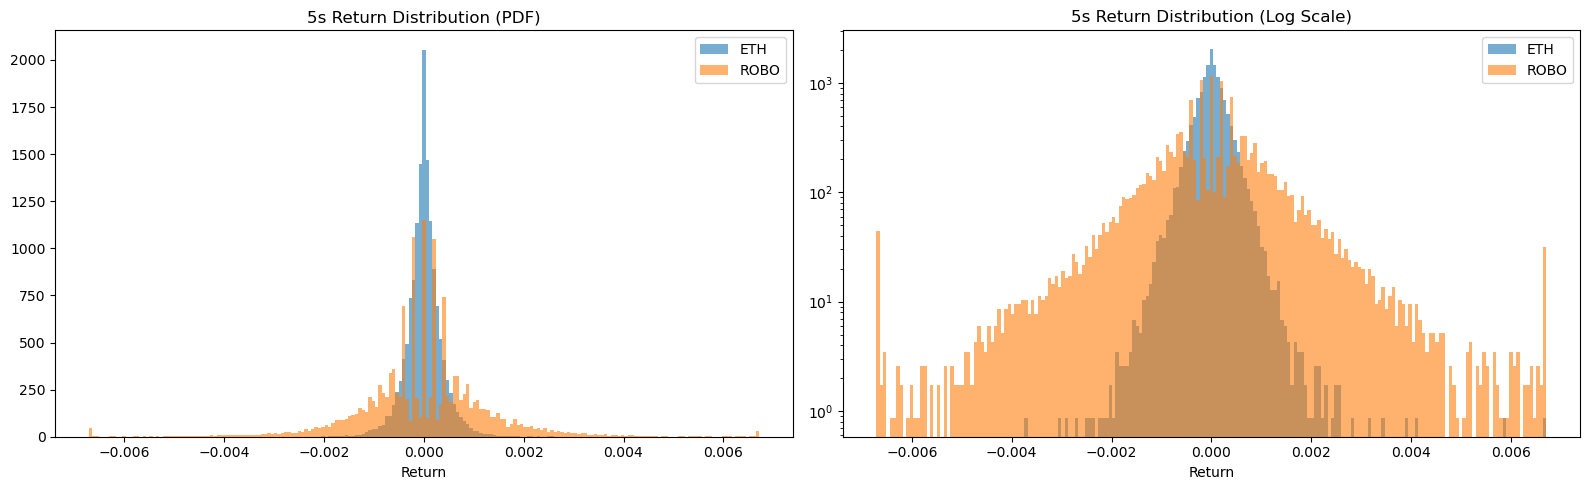

In [3]:
# 分布对比图
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 直方图对比
clip = max(robo_ret.abs().quantile(0.995), eth_ret.abs().quantile(0.995))
bins = np.linspace(-clip, clip, 200)
axes[0].hist(eth_ret.clip(-clip, clip), bins=bins, alpha=0.6, density=True, label='ETH')
axes[0].hist(robo_ret.clip(-clip, clip), bins=bins, alpha=0.6, density=True, label='ROBO')
axes[0].set_title('5s Return Distribution (PDF)')
axes[0].set_xlabel('Return')
axes[0].legend()

# Log-scale 看尾部
axes[1].hist(eth_ret.clip(-clip, clip), bins=bins, alpha=0.6, density=True, label='ETH')
axes[1].hist(robo_ret.clip(-clip, clip), bins=bins, alpha=0.6, density=True, label='ROBO')
axes[1].set_yscale('log')
axes[1].set_title('5s Return Distribution (Log Scale)')
axes[1].set_xlabel('Return')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
robo_ret

In [4]:
# 尾部极端事件统计
thresholds = [0.001, 0.002, 0.005, 0.01, 0.02]
tail_stats = []
for t in thresholds:
    robo_pct = (robo_ret.abs() > t).mean() * 100
    eth_pct = (eth_ret.abs() > t).mean() * 100
    ratio = robo_pct / eth_pct if eth_pct > 0 else float('inf')
    tail_stats.append({'threshold': f'|ret| > {t:.1%}', 'ROBO%': f'{robo_pct:.2f}%', 'ETH%': f'{eth_pct:.2f}%', 'ROBO/ETH': f'{ratio:.1f}x'})

print(pd.DataFrame(tail_stats).to_string(index=False))

   threshold  ROBO%  ETH% ROBO/ETH
|ret| > 0.1% 33.01% 2.23%    14.8x
|ret| > 0.2% 10.89% 0.20%    55.4x
|ret| > 0.5%  1.07% 0.01%    92.0x
|ret| > 1.0%  0.24% 0.00%     infx
|ret| > 2.0%  0.06% 0.00%     infx


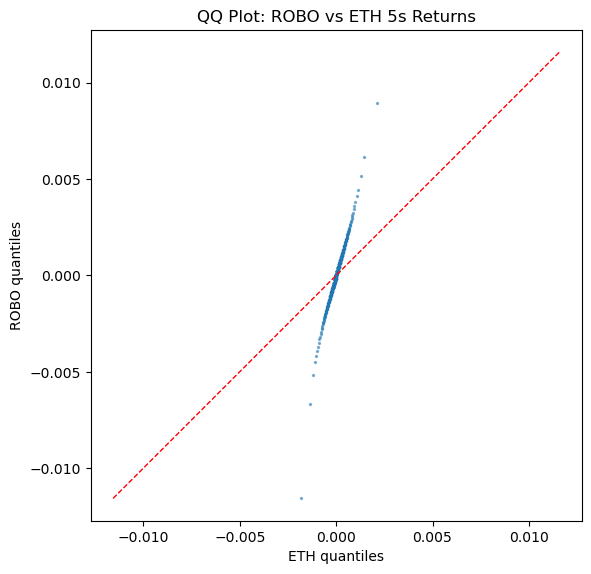

In [5]:
# QQ Plot: ROBO vs ETH 分位数对比
fig, ax = plt.subplots(figsize=(6, 6))
quantiles = np.linspace(0.001, 0.999, 500)
eth_q = np.quantile(eth_ret, quantiles)
robo_q = np.quantile(robo_ret, quantiles)
ax.scatter(eth_q, robo_q, s=2, alpha=0.5)
lim = max(abs(eth_q).max(), abs(robo_q).max())
ax.plot([-lim, lim], [-lim, lim], 'r--', lw=1)
ax.set_xlabel('ETH quantiles')
ax.set_ylabel('ROBO quantiles')
ax.set_title('QQ Plot: ROBO vs ETH 5s Returns')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()